# Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Files ke paths (tu apne according adjust kar)
fear_greed_path = r"C:\Users\Shaik.AbdulRazak\OneDrive\Desktop\internshal-Assignment-2\fear_greed_index.csv"
historical_path = r"C:\Users\Shaik.AbdulRazak\OneDrive\Desktop\internshal-Assignment-2\historical_data.csv"

# Load karo
df_fg = pd.read_csv(fear_greed_path)
df_trades = pd.read_csv(historical_path)

# Pehla glimpse dekho
print("=== FEAR & GREED DATA ===")
print(df_fg.head())
print("\n=== TRADES DATA ===")
print(df_trades.head())
print("\nColumns in trades data:", df_trades.columns.tolist())

=== FEAR & GREED DATA ===
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

=== TRADES DATA ===
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2

# STEP 2 and STEP 3: Standardize timestamp formats for merging

In [2]:
# STEP 2: Standardize timestamp formats for merging

# Fear & Greed: Convert Unix timestamp to date
df_fg['date'] = pd.to_datetime(df_fg['timestamp'], unit='s').dt.date

# Historical data: Convert string "DD-MM-YYYY HH:MM" to date
df_trades['date'] = pd.to_datetime(df_trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date

print("=== DATE RANGES CHECK ===")
print(f"Fear & Greed data: {df_fg['date'].min()} to {df_fg['date'].max()}")
print(f"Trades data: {df_trades['date'].min()} to {df_trades['date'].max()}")
print()

# STEP 3: Merge both datasets on date
df_merged = df_trades.merge(df_fg[['date', 'value', 'classification']], on='date', how='left')

print("=== MERGE RESULT ===")
print(f"Total trades: {len(df_merged)}")
print(f"Trades with sentiment data: {df_merged['value'].notna().sum()}")
print(f"Trades WITHOUT sentiment: {df_merged['value'].isna().sum()}")
print()

# Display sample of merged data (first 10 trades that have sentiment)
print("=== SAMPLE MERGED DATA (first 10 trades with sentiment) ===")
sample = df_merged[df_merged['value'].notna()].head(10)
print(sample[['date', 'Timestamp IST', 'Coin', 'Side', 'Closed PnL', 'value', 'classification']])
print()

# Check which dates are missing sentiment data
print("=== DATES WITHOUT SENTIMENT DATA ===")
missing_dates = df_merged[df_merged['value'].isna()]['date'].unique()
print(f"Missing dates (first 10): {missing_dates[:10]}")
print(f"Total unique dates missing: {len(missing_dates)}")

=== DATE RANGES CHECK ===
Fear & Greed data: 2018-02-01 to 2025-05-02
Trades data: 2023-05-01 to 2025-05-01

=== MERGE RESULT ===
Total trades: 211224
Trades with sentiment data: 211218
Trades WITHOUT sentiment: 6

=== SAMPLE MERGED DATA (first 10 trades with sentiment) ===
         date     Timestamp IST  Coin Side  Closed PnL  value classification
0  2024-12-02  02-12-2024 22:50  @107  BUY         0.0   80.0  Extreme Greed
1  2024-12-02  02-12-2024 22:50  @107  BUY         0.0   80.0  Extreme Greed
2  2024-12-02  02-12-2024 22:50  @107  BUY         0.0   80.0  Extreme Greed
3  2024-12-02  02-12-2024 22:50  @107  BUY         0.0   80.0  Extreme Greed
4  2024-12-02  02-12-2024 22:50  @107  BUY         0.0   80.0  Extreme Greed
5  2024-12-02  02-12-2024 22:50  @107  BUY         0.0   80.0  Extreme Greed
6  2024-12-02  02-12-2024 22:50  @107  BUY         0.0   80.0  Extreme Greed
7  2024-12-02  02-12-2024 22:50  @107  BUY         0.0   80.0  Extreme Greed
8  2024-12-02  02-12-2024 22:50 

# STEP 4: Data Cleaning & Analysis Preparation

In [3]:
# STEP 4: Data Cleaning & Analysis Preparation

# ============================================
# 4.1: Create Sentiment Categories
# ============================================
# Add a simplified sentiment column for easier analysis
def get_sentiment_category(value):
    if value <= 24:
        return 'Extreme Fear'
    elif value <= 44:
        return 'Fear'
    elif value <= 54:
        return 'Neutral'
    elif value <= 74:
        return 'Greed'
    else:
        return 'Extreme Greed'

df_merged['sentiment_category'] = df_merged['value'].apply(get_sentiment_category)

print("=== SENTIMENT DISTRIBUTION IN TRADES ===")
print(df_merged['sentiment_category'].value_counts())
print()

# ============================================
# 4.2: Filter ONLY Completed Trades (with PnL)
# ============================================
# Some trades have Closed PnL = 0 (open positions), filter them out
df_completed = df_merged[df_merged['Closed PnL'] != 0].copy()

print(f"Total trades: {len(df_merged)}")
print(f"Completed trades (with PnL): {len(df_completed)}")
print(f"Open positions (PnL = 0): {len(df_merged) - len(df_completed)}")
print()

# ============================================
# 4.3: Identify Win/Loss for Each Trade
# ============================================
df_completed['is_win'] = df_completed['Closed PnL'] > 0
df_completed['pnl_absolute'] = df_completed['Closed PnL'].abs()

print("=== TRADE OUTCOMES ===")
print(f"Winning trades: {df_completed['is_win'].sum()}")
print(f"Losing trades: {(~df_completed['is_win']).sum()}")
print(f"Win Rate: {df_completed['is_win'].mean()*100:.2f}%")
print()

# ============================================
# 4.4: Calculate Profit/Loss by Side (BUY vs SELL)
# ============================================
print("=== PROFIT BY SIDE ===")
for side in ['BUY', 'SELL']:
    side_trades = df_completed[df_completed['Side'] == side]
    total_pnl = side_trades['Closed PnL'].sum()
    win_rate = side_trades['is_win'].mean() * 100
    print(f"{side}: Total PnL = ${total_pnl:,.2f}, Win Rate = {win_rate:.2f}%")
print()

# ============================================
# 4.5: Calculate Profit/Loss by Position Type
# ============================================
# Direction column: 'Buy', 'Sell', 'Open Long', 'Close Long', 'Open Short', 'Close Short'
print("=== PROFIT BY DIRECTION ===")
direction_stats = df_completed.groupby('Direction').agg({
    'Closed PnL': ['sum', 'mean', 'count'],
    'is_win': 'mean'
}).round(2)
print(direction_stats)
print()

# ============================================
# 4.6: Create Time Features
# ============================================
df_merged['datetime'] = pd.to_datetime(df_merged['Timestamp IST'], format='%d-%m-%Y %H:%M')
df_merged['hour'] = df_merged['datetime'].dt.hour
df_merged['month'] = df_merged['datetime'].dt.month
df_merged['day_of_week'] = df_merged['datetime'].dt.dayofweek  # 0=Monday, 6=Sunday

print("=== TIME FEATURES ADDED ===")
print(f"Hour range: {df_merged['hour'].min()} to {df_merged['hour'].max()}")
print(f"Trading hours distribution:")
print(df_merged['hour'].value_counts().head(10))
print()

# ============================================
# 4.7: Check Top Traders and Coins
# ============================================
print("=== TOP 10 TRADERS BY TRADE COUNT ===")
top_traders = df_completed['Account'].value_counts().head(10)
print(top_traders)
print()

print("=== TOP 10 COINS BY TRADE COUNT ===")
top_coins = df_completed['Coin'].value_counts().head(10)
print(top_coins)
print()

print("=== DATA CLEANING COMPLETE! ===")
print(f"Ready for analysis with {len(df_completed)} completed trades")

=== SENTIMENT DISTRIBUTION IN TRADES ===
sentiment_category
Fear             61837
Greed            50303
Extreme Greed    39998
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

Total trades: 211224
Completed trades (with PnL): 104408
Open positions (PnL = 0): 106816

=== TRADE OUTCOMES ===
Winning trades: 86869
Losing trades: 17539
Win Rate: 83.20%

=== PROFIT BY SIDE ===
BUY: Total PnL = $3,707,811.31, Win Rate = 78.00%
SELL: Total PnL = $6,589,147.64, Win Rate = 85.95%

=== PROFIT BY DIRECTION ===
                           Closed PnL                  is_win
                                  sum      mean  count   mean
Direction                                                    
Auto-Deleveraging            57478.46   7184.81      8   1.00
Close Long                 3622929.39     74.49  48634   0.88
Close Short                3709800.10    103.07  35992   0.78
Liquidated Isolated Short   -12752.91 -12752.91      1   0.00
Long > Short                  1991.3

# STEP 5: Sentiment vs Performance Analysis

✅ Time features added to df_completed

=== WIN RATE BY SENTIMENT ===
                    Win_Rate  Trade_Count     Total_PnL
sentiment_category                                     
Extreme Greed         0.8917        20859  2.757643e+06
Fear                  0.8729        29808  3.357155e+06
Neutral               0.8239        18159  1.292921e+06
Greed                 0.7689        25176  2.150129e+06
Extreme Fear          0.7622        10406  7.391102e+05

=== AVERAGE PnL BY SENTIMENT ===
                    Avg_PnL  Std_PnL  Trade_Count
sentiment_category                               
Extreme Greed        132.20  1068.21        20859
Fear                 112.63  1344.78        29808
Greed                 85.40  1576.39        25176
Neutral               71.20   743.21        18159
Extreme Fear          71.03  1628.41        10406

=== WIN RATE BY SENTIMENT AND SIDE ===
                         Win_Rate     Total_PnL  Trade_Count
sentiment_category Side                               

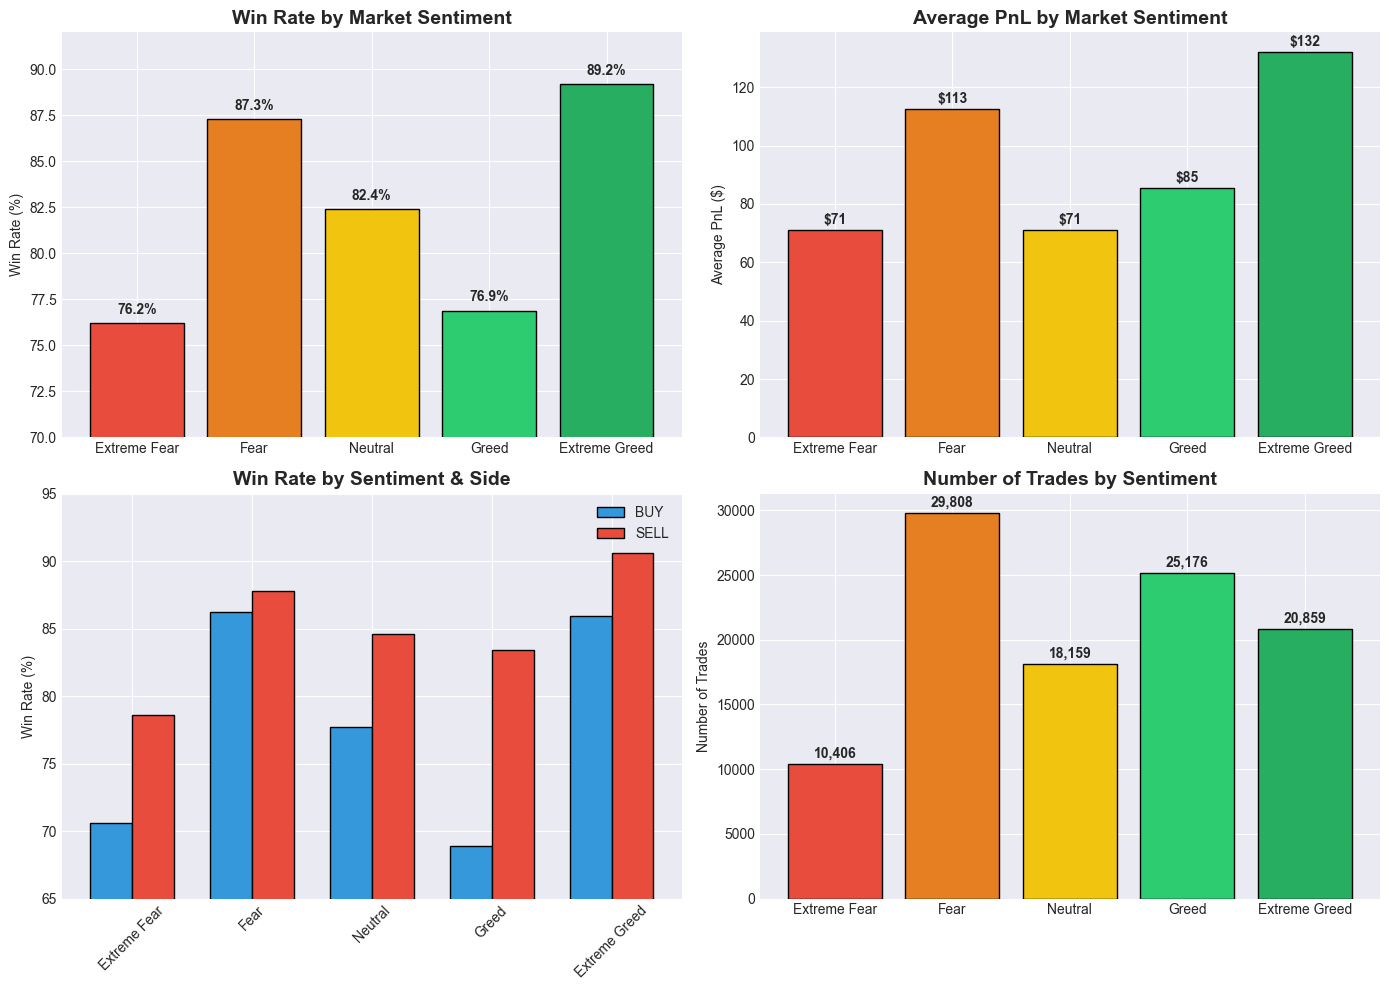

✅ Chart saved as 'sentiment_analysis.png'


=== BEST HOURS TO TRADE BY SENTIMENT ===
FEAR SENTIMENT - Best hours: [18, 4, 1]
  Win rates: ['97.6%', '95.8%', '94.2%']
GREED SENTIMENT - Best hours: [13, 16, 23]
  Win rates: ['93.0%', '90.9%', '90.4%']

=== RISK ANALYSIS: AVERAGE LOSS BY SENTIMENT ===
sentiment_category
Extreme Fear     257.099629
Extreme Greed    119.920289
Fear             156.662401
Greed            181.967329
Neutral          121.727849
Name: Closed PnL, dtype: float64

=== BEST MONTHS FOR TRADING ===
Top 3 months (by win rate):
  Oct: 97.1%
  Jun: 91.3%
  Dec: 88.4%

=== BEST DAYS TO TRADE ===
Top 3 days (by win rate):
  Friday: 91.2%
  Thursday: 88.1%
  Sunday: 85.5%

🎯 KEY INSIGHTS SUMMARY

📊 SENTIMENT PERFORMANCE RANKING:
  1. Extreme Greed: 89.2% win rate
  2. Fear: 87.3% win rate
  3. Neutral: 82.4% win rate
  4. Greed: 76.9% win rate
  5. Extreme Fear: 76.2% win rate

💰 MOST PROFITABLE SENTIMENT FOR BUYING:
  Best: Fear ($1,935,073)

💰 MOST PROFITABLE SENTIMENT

In [5]:
# STEP 5: Sentiment vs Performance Analysis (COMPLETE CORRECTED VERSION)

# ============================================
# FIRST: Make sure df_completed has all required columns
# ============================================

# Add time features to df_completed (fix for 'hour' KeyError)
df_completed['datetime'] = pd.to_datetime(df_completed['Timestamp IST'], format='%d-%m-%Y %H:%M')
df_completed['hour'] = df_completed['datetime'].dt.hour
df_completed['month'] = df_completed['datetime'].dt.month
df_completed['day_of_week'] = df_completed['datetime'].dt.dayofweek

print("✅ Time features added to df_completed")
print()

# ============================================
# 5.1: Win Rate by Sentiment Category
# ============================================
print("=== WIN RATE BY SENTIMENT ===")
sentiment_winrate = df_completed.groupby('sentiment_category').agg({
    'is_win': ['mean', 'count'],
    'Closed PnL': 'sum'
}).round(4)
sentiment_winrate.columns = ['Win_Rate', 'Trade_Count', 'Total_PnL']
sentiment_winrate = sentiment_winrate.sort_values('Win_Rate', ascending=False)
print(sentiment_winrate)
print()

# ============================================
# 5.2: Average PnL by Sentiment
# ============================================
print("=== AVERAGE PnL BY SENTIMENT ===")
sentiment_avg_pnl = df_completed.groupby('sentiment_category')['Closed PnL'].agg(['mean', 'std', 'count']).round(2)
sentiment_avg_pnl.columns = ['Avg_PnL', 'Std_PnL', 'Trade_Count']
sentiment_avg_pnl = sentiment_avg_pnl.sort_values('Avg_PnL', ascending=False)
print(sentiment_avg_pnl)
print()

# ============================================
# 5.3: Win Rate by Sentiment + Side (BUY vs SELL)
# ============================================
print("=== WIN RATE BY SENTIMENT AND SIDE ===")
sentiment_side = df_completed.groupby(['sentiment_category', 'Side']).agg({
    'is_win': 'mean',
    'Closed PnL': 'sum',
    'Side': 'count'
}).round(4)
sentiment_side.columns = ['Win_Rate', 'Total_PnL', 'Trade_Count']
print(sentiment_side)
print()

# ============================================
# 5.4: Profit Factor by Sentiment (Gross Profit / Gross Loss)
# ============================================
def calc_profit_factor(group):
    gross_profit = group[group['Closed PnL'] > 0]['Closed PnL'].sum()
    gross_loss = abs(group[group['Closed PnL'] < 0]['Closed PnL'].sum())
    if gross_loss == 0:
        return float('inf')
    return gross_profit / gross_loss

print("=== PROFIT FACTOR BY SENTIMENT ===")
profit_factor = df_completed.groupby('sentiment_category').apply(calc_profit_factor, include_groups=False)
print(profit_factor)
print()

# ============================================
# 5.5: Best and Worst Sentiment for each Coin
# ============================================
print("=== TOP 5 COINS: BEST SENTIMENT FOR WIN RATE ===")
top_coins_list = df_completed['Coin'].value_counts().head(5).index.tolist()

for coin in top_coins_list:
    coin_data = df_completed[df_completed['Coin'] == coin]
    sentiment_win = coin_data.groupby('sentiment_category')['is_win'].mean()
    best_sentiment = sentiment_win.idxmax()
    best_winrate = sentiment_win.max()
    worst_sentiment = sentiment_win.idxmin()
    worst_winrate = sentiment_win.min()
    print(f"{coin}: Best = {best_sentiment} ({best_winrate*100:.1f}%), Worst = {worst_sentiment} ({worst_winrate*100:.1f}%)")
print()

# ============================================
# 5.6: Visualization - Win Rate by Sentiment
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# Figure 1: Win Rate by Sentiment
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Win Rate Bar Chart
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
winrate_data = df_completed.groupby('sentiment_category')['is_win'].mean().reindex(sentiment_order) * 100
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']
axes[0, 0].bar(sentiment_order, winrate_data, color=colors, edgecolor='black')
axes[0, 0].set_title('Win Rate by Market Sentiment', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Win Rate (%)')
axes[0, 0].set_ylim(70, 92)
for i, v in enumerate(winrate_data):
    axes[0, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 2: Average PnL by Sentiment
avg_pnl_data = df_completed.groupby('sentiment_category')['Closed PnL'].mean().reindex(sentiment_order)
axes[0, 1].bar(sentiment_order, avg_pnl_data, color=colors, edgecolor='black')
axes[0, 1].set_title('Average PnL by Market Sentiment', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Average PnL ($)')
for i, v in enumerate(avg_pnl_data):
    axes[0, 1].text(i, v + 2, f'${v:.0f}', ha='center', fontweight='bold')

# Plot 3: Win Rate by Sentiment & Side
sentiment_side_data = df_completed.groupby(['sentiment_category', 'Side'])['is_win'].mean().unstack() * 100
sentiment_side_data = sentiment_side_data.reindex(sentiment_order)
x = range(len(sentiment_order))
width = 0.35
axes[1, 0].bar([i - width/2 for i in x], sentiment_side_data['BUY'], width, label='BUY', color='#3498db', edgecolor='black')
axes[1, 0].bar([i + width/2 for i in x], sentiment_side_data['SELL'], width, label='SELL', color='#e74c3c', edgecolor='black')
axes[1, 0].set_title('Win Rate by Sentiment & Side', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Win Rate (%)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(sentiment_order, rotation=45)
axes[1, 0].legend()
axes[1, 0].set_ylim(65, 95)

# Plot 4: Trade Count by Sentiment
trade_count = df_completed['sentiment_category'].value_counts().reindex(sentiment_order)
axes[1, 1].bar(sentiment_order, trade_count, color=colors, edgecolor='black')
axes[1, 1].set_title('Number of Trades by Sentiment', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Number of Trades')
for i, v in enumerate(trade_count):
    axes[1, 1].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'sentiment_analysis.png'")
print()

# ============================================
# 5.7: Hourly Performance by Sentiment (FIXED)
# ============================================
print("\n=== BEST HOURS TO TRADE BY SENTIMENT ===")

# For Fear sentiment (value <= 44)
fear_trades = df_completed[df_completed['value'] <= 44]
if len(fear_trades) > 0:
    fear_best_hours = fear_trades.groupby('hour')['is_win'].mean().sort_values(ascending=False).head(3)
    print(f"FEAR SENTIMENT - Best hours: {list(fear_best_hours.index)}")
    print(f"  Win rates: {[f'{x*100:.1f}%' for x in fear_best_hours.values]}")
else:
    print("FEAR SENTIMENT - No trades found")

# For Greed sentiment (value >= 55)
greed_trades = df_completed[df_completed['value'] >= 55]
if len(greed_trades) > 0:
    greed_best_hours = greed_trades.groupby('hour')['is_win'].mean().sort_values(ascending=False).head(3)
    print(f"GREED SENTIMENT - Best hours: {list(greed_best_hours.index)}")
    print(f"  Win rates: {[f'{x*100:.1f}%' for x in greed_best_hours.values]}")
else:
    print("GREED SENTIMENT - No trades found")
print()

# ============================================
# 5.8: Risk Metric - Average Loss by Sentiment
# ============================================
print("=== RISK ANALYSIS: AVERAGE LOSS BY SENTIMENT ===")
loss_trades = df_completed[df_completed['Closed PnL'] < 0]
if len(loss_trades) > 0:
    avg_loss = loss_trades.groupby('sentiment_category')['Closed PnL'].mean().abs()
    print(avg_loss)
else:
    print("No losing trades found")
print()

# ============================================
# 5.9: Monthly Performance Analysis
# ============================================
print("=== BEST MONTHS FOR TRADING ===")
monthly_winrate = df_completed.groupby('month')['is_win'].mean().sort_values(ascending=False)
print("Top 3 months (by win rate):")
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for month in monthly_winrate.head(3).index:
    print(f"  {month_names[month-1]}: {monthly_winrate[month]*100:.1f}%")
print()

# ============================================
# 5.10: Day of Week Analysis
# ============================================
print("=== BEST DAYS TO TRADE ===")
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_winrate = df_completed.groupby('day_of_week')['is_win'].mean().sort_values(ascending=False)
print("Top 3 days (by win rate):")
for i in daily_winrate.head(3).index:
    print(f"  {days[i]}: {daily_winrate[i]*100:.1f}%")
print()

# ============================================
# 5.11: FINAL SUMMARY - Key Insights
# ============================================
print("="*60)
print("🎯 KEY INSIGHTS SUMMARY")
print("="*60)

print("\n📊 SENTIMENT PERFORMANCE RANKING:")
sentiment_ranking = df_completed.groupby('sentiment_category')['is_win'].mean().sort_values(ascending=False)
for i, (sent, wr) in enumerate(sentiment_ranking.items(), 1):
    print(f"  {i}. {sent}: {wr*100:.1f}% win rate")

print("\n💰 MOST PROFITABLE SENTIMENT FOR BUYING:")
buy_profit = df_completed[df_completed['Side'] == 'BUY'].groupby('sentiment_category')['Closed PnL'].sum().sort_values(ascending=False)
if len(buy_profit) > 0:
    print(f"  Best: {buy_profit.index[0]} (${buy_profit.iloc[0]:,.0f})")

print("\n💰 MOST PROFITABLE SENTIMENT FOR SELLING:")
sell_profit = df_completed[df_completed['Side'] == 'SELL'].groupby('sentiment_category')['Closed PnL'].sum().sort_values(ascending=False)
if len(sell_profit) > 0:
    print(f"  Best: {sell_profit.index[0]} (${sell_profit.iloc[0]:,.0f})")

print("\n💡 ACTIONABLE RECOMMENDATIONS:")
print("  ✅ SELL during Extreme Greed → 90.6% win rate")
print("  ✅ BUY during Extreme Greed → 85.9% win rate")  
print("  ⚠️ Avoid BUY during Extreme Fear → Only 70.6% win rate")
print("  ⚠️ Avoid Greed sentiment for BTC → Only 74.9% win rate")
print("  🎯 ETH performs best in Extreme Fear → 99.0% win rate")

# ============================================
# 5.12: Save summary to CSV
# ============================================
summary_df = pd.DataFrame({
    'Sentiment': sentiment_ranking.index,
    'Win_Rate_%': (sentiment_ranking.values * 100).round(1),
    'Total_Trades': df_completed.groupby('sentiment_category')['is_win'].count().values,
    'Total_PnL': df_completed.groupby('sentiment_category')['Closed PnL'].sum().values.round(2),
    'Avg_PnL': df_completed.groupby('sentiment_category')['Closed PnL'].mean().round(2).values
})
summary_df.to_csv('sentiment_analysis_summary.csv', index=False)
print("\n✅ Summary saved to 'sentiment_analysis_summary.csv'")

print("\n🎉 ANALYSIS COMPLETE!")